In [11]:
import json

def get_metric_value(file_name, dataset_name):
    try:
        with open(file_name, 'r') as file:
            data = json.load(file)[dataset_name]
    except FileNotFoundError:
        return 0
        
    keys = list(data.keys())  
    metric = keys[1]
    value = data[metric]
    
    return value
 
model_name = "llama3-1b"   
    
datasets = ["squadv2", "mlqa_en_en", "wmt16-de-en", "wmt16-ro-en", "xsum", "cnn_dailymail"]
methods = [
    {"folder": "partinfer_results", "filename": f"partinfer_{model_name}.json", "name": "partinfer"},
    {"folder": "coreinfer_results", "filename": f"coreinfer_{model_name}.json", "name": "coreinfer"},
    {"folder": "coreinfer_results", "filename": f"coreinfer_partial_loading_{model_name}.json", "name": "coreinfer_default_partial"},
    {"folder": "coreinfer_results", "filename": f"coreinfer_random_loading_{model_name}.json", "name": "coreinfer_random_partial"},
    {"folder": "dense_results", "filename": f"dense_{model_name}.json", "name": "dense"},
]

results = {}
for dataset in datasets:
    for method in methods:
        folder = method["folder"]
        filename = method["filename"]
        name = method["name"]
        file_name = f"{folder}/{dataset}/{filename}"
        value = get_metric_value(file_name, dataset)
        
        if dataset not in results:
            results[dataset] = {}
            
        results[dataset][name] = value

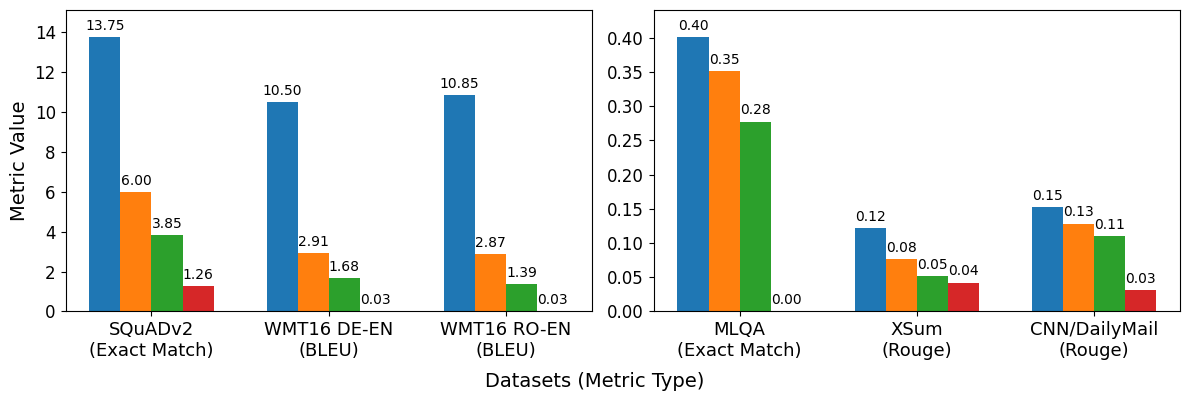

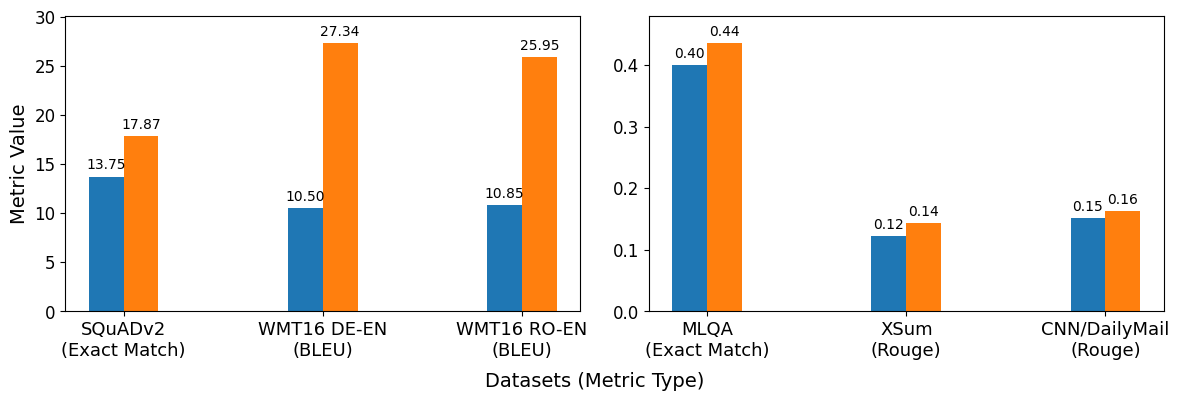

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Group datasets into two subplots
subplot1 = ["squadv2", "wmt16-de-en", "wmt16-ro-en"]
subplot2 = ["mlqa_en_en", "xsum", "cnn_dailymail"]

graphs = [
    ["partinfer", "coreinfer", "coreinfer_default_partial", "coreinfer_random_partial"],
    ["partinfer", "dense"],
]

method_labels = {
    "partinfer": "PartInfer",
    "coreinfer": "CoreInfer",
    "partinfer_modified": "PartInfer Modified",
    "coreinfer_default_partial": "CoreInfer + Our Partial Loading",
    "coreinfer_random_partial": "CoreInfer + Random Partial Loading",
    "reference": "Reference",
    "dense": "Dense 70%"
}

labels = {
    "squadv2": "SQuADv2\n(Exact Match)",
    "mlqa_en_en": "MLQA\n(Exact Match)",
    "wmt16-de-en": "WMT16 DE-EN\n(BLEU)",
    "wmt16-ro-en": "WMT16 RO-EN\n(BLEU)",
    "xsum": "XSum\n(Rouge)",
    "cnn_dailymail": "CNN/DailyMail\n(Rouge)"
}

for graph in graphs:

    # Filter the results to only the relevant methods
    included_results = {}
    for dataset, metrics in results.items():
        included_results[dataset] = {}
        for method, value in metrics.items():
            if method in graph:
                included_results[dataset][method] = value

    method_names = list(next(iter(included_results.values())).keys())
    bar_width = 0.175

    # ------------------------------------------
    #         CREATE FIGURE WITH 2 SUBPLOTS
    # ------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

    # ------------------------------------------
    # Subplot 1 (3 datasets)
    # ------------------------------------------
    x1 = subplot1
    r1 = np.arange(len(x1))

    ax1 = axes[0]
    for i, method in enumerate(method_names):
        y = [included_results[ds][method] for ds in x1]
        xpos = r1 + i * bar_width
        bars = ax1.bar(xpos, y, bar_width, label=method_labels[method])

        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax1.annotate(
                f"{height:.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=10
            )

    ax1.set_xticks(r1 + bar_width * (len(method_names)-1)/2)
    ax1.set_xticklabels([labels[d] for d in x1], fontsize=13)
    ax1.set_ylabel("Metric Value", fontsize=14)
    ax1.tick_params(axis='y', labelsize=12)

    # Increase y-limit by 10% for subplot 1
    max_y1 = max(included_results[ds][m] for ds in x1 for m in method_names)
    ax1.set_ylim(0, max_y1 * 1.1)

    # ------------------------------------------
    # Subplot 2 (3 datasets)
    # ------------------------------------------
    x2 = subplot2
    r2 = np.arange(len(x2))

    ax2 = axes[1]
    for i, method in enumerate(method_names):
        y = [included_results[ds][method] for ds in x2]
        xpos = r2 + i * bar_width
        bars = ax2.bar(xpos, y, bar_width)

        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax2.annotate(
                f"{height:.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=10
            )

    ax2.set_xticks(r2 + bar_width * (len(method_names)-1)/2)
    ax2.set_xticklabels([labels[d] for d in x2], fontsize=13)
    ax2.tick_params(axis='y', labelsize=12)

    # Increase y-limit by 10% for subplot 2
    max_y2 = max(included_results[ds][m] for ds in x2 for m in method_names)
    ax2.set_ylim(0, max_y2 * 1.1)

    # ------------------------------------------
    # Shared Legend
    # ------------------------------------------
    if model_name == "llama3-3b":
        handles, legend_labels = ax1.get_legend_handles_labels()
        fig.legend(handles, legend_labels, fontsize=12, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.08))

    # ------------------------------------------
    # Shared X Label
    # ------------------------------------------
    if model_name == "llama3-1b":
        fig.text(0.5, 0.02, "Datasets (Metric Type)", ha="center", fontsize=14)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


# Analyze SpeedUp

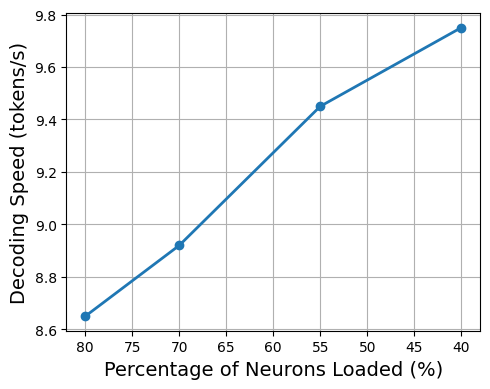

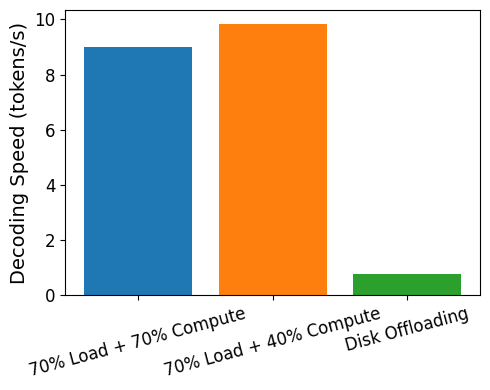

In [3]:
import matplotlib.pyplot as plt

# ---------------- Graph 1: Partial Loading ----------------
loading_perc = [80, 70, 55, 40]
throughput_loading = [8.65, 8.92, 9.45, 9.75]

plt.figure(figsize=(5,4))
plt.plot(loading_perc, throughput_loading, marker='o', linewidth=2)
plt.xlabel("Percentage of Neurons Loaded (%)", fontsize=14)
plt.ylabel("Decoding Speed (tokens/s)", fontsize=14)
# plt.title("Effect of Partial Loading on Decoding Speed")
plt.grid(True)
plt.gca().invert_xaxis()  # more intuitive: less loading → more speed
plt.tight_layout()
# plt.savefig("partial_loading.png", dpi=300)
plt.show()

# ---------------- Graph 2: Partial Computation ----------------
methods = ["70% Load + 70% Compute", "70% Load + 40% Compute", "Disk Offloading"]
throughput_comp = [9.0, 9.85, 0.75]

plt.figure(figsize=(5,4))
bars = plt.bar(methods, throughput_comp, color=["#1f77b4", "#ff7f0e", "#2ca02c"])

plt.ylabel("Decoding Speed (tokens/s)", fontsize=14)
plt.tick_params(axis='y', labelsize=12)
plt.tick_params(axis='x', labelsize=12)
plt.xticks(rotation=15)
# plt.ylim(8, max(throughput_comp) + 0.2)
# plt.title("Effect of Partial Computation on Decoding Speed")
plt.tight_layout()
# plt.savefig("partial_computation.png", dpi=300)
plt.show()


## Ablation Studies

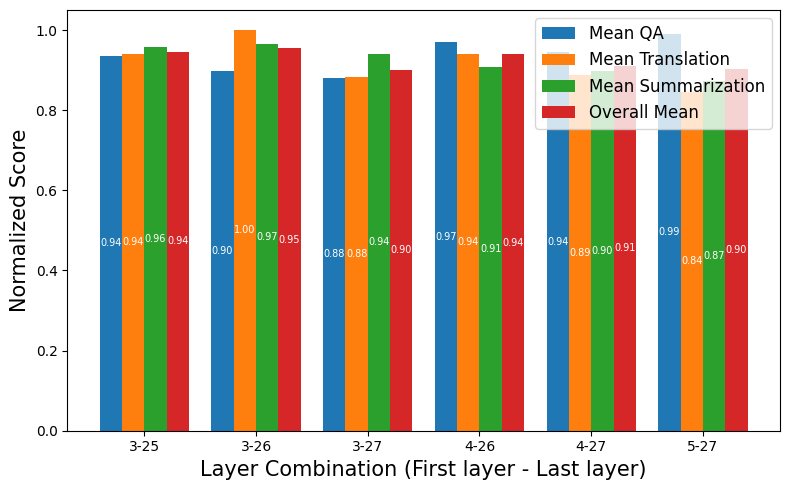

In [38]:
# Raw data (converted to Python floats)
data = {
    "3-25": [0.18, 24, 20.68, 25.41, 0.1046, 0.1078],
    "3-26": [0.168, 23.6, 21.63, 27.47, 0.114, 0.1004],
    "3-27": [0.168, 22.8, 19.51, 23.73, 0.1074, 0.101],
    "4-26": [0.184, 25.2, 19.51, 26.93, 0.1096, 0.0921],
    "4-27": [0.196, 22.4, 19.61, 23.91, 0.1095, 0.0901],
    "5-27": [0.192, 25.2, 18.51, 22.91, 0.1103, 0.0838],
}

layer_names = list(data.keys())

# Convert to array for normalization
values = np.array(list(data.values()))  # shape: (6 combinations, 6 tasks)

# Compute max per task (column)
task_max = values.max(axis=0)

# Normalize
normalized_values = values / task_max

# Prepare metric arrays
mean_qa = []
mean_translation = []
mean_summarization = []
mean_overall = []

for row in normalized_values:
    qa = np.mean(row[0:2])               # TriviaQA + SQuADv2
    translation = np.mean(row[2:4])      # WMT RO + WMT DE
    summarization = np.mean(row[4:6])    # XSum + CNN/DM
    overall = np.mean(row)               # All 6 tasks

    mean_qa.append(qa)
    mean_translation.append(translation)
    mean_summarization.append(summarization)
    mean_overall.append(overall)

# Plotting
x = np.arange(len(layer_names))
width = 0.2

plt.figure(figsize=(8, 5))

b1 = plt.bar(x - 1.5*width, mean_qa, width, label="Mean QA")
b2 = plt.bar(x - 0.5*width, mean_translation, width, label="Mean Translation")
b3 = plt.bar(x + 0.5*width, mean_summarization, width, label="Mean Summarization")
b4 = plt.bar(x + 1.5*width, mean_overall, width, label="Overall Mean")

# Write the value of each bar in the middle of it
for bar_container in (b1, b2, b3, b4):
    for bar in bar_container:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,                     # middle of the bar vertically
            f"{height:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="white" if height > 0.5 else "black"  # contrast
        )

# Increase tick label font sizes for both axes
plt.xticks(x, layer_names, fontsize=10)
plt.tick_params(axis='y', labelsize=10)

plt.ylabel("Normalized Score", fontsize=15)
plt.xlabel("Layer Combination (First layer - Last layer)", fontsize=15)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


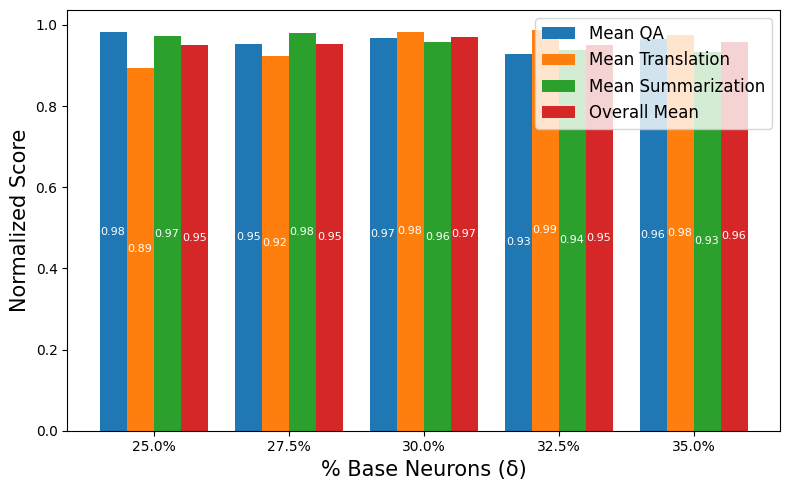

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Data (converted to Python floats)
# NOTE: First column is % of base neurons → used only as label, not part of metrics
data = {
    "25.0%": [0.2, 21.2, 18.03, 24.1, 0.107, 0.09324],
    "27.5%": [0.196, 20.4, 19.09, 24.29, 0.1134, 0.08966],
    "30.0%": [0.198, 20.8, 20.38, 25.73, 0.1078, 0.08984],
    "32.5%": [0.188, 20.2, 19.87, 26.63, 0.1083, 0.08592],
    "35.0%": [0.186, 22.0, 19.88, 26.0, 0.1096, 0.084]
}

labels = list(data.keys())

# Extract values into array shape (7 combos, 6 tasks)
values = np.array(list(data.values()))

# Normalize each column by task max
task_max = values.max(axis=0)
normalized_values = values / task_max

# Compute mean metrics
mean_qa = []
mean_translation = []
mean_summarization = []
mean_overall = []

for row in normalized_values:
    qa = np.mean(row[0:2])               # Trivia + Squad
    translation = np.mean(row[2:4])      # RO + DE
    summarization = np.mean(row[4:6])    # XSum + CNN
    overall = np.mean(row)               # All 6 tasks

    mean_qa.append(qa)
    mean_translation.append(translation)
    mean_summarization.append(summarization)
    mean_overall.append(overall)

# Plot
x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(8, 5))

b1 = plt.bar(x - 1.5*width, mean_qa, width, label="Mean QA")
b2 = plt.bar(x - 0.5*width, mean_translation, width, label="Mean Translation")
b3 = plt.bar(x + 0.5*width, mean_summarization, width, label="Mean Summarization")
b4 = plt.bar(x + 1.5*width, mean_overall, width, label="Overall Mean")

# Write the value of each bar in the middle of it
for bar_container in (b1, b2, b3, b4):
    for bar in bar_container:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,                     # middle of the bar vertically
            f"{height:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if height > 0.5 else "black"  # contrast
        )

plt.xticks(x, labels, fontsize=10)
plt.tick_params(axis='y', labelsize=10)

plt.ylabel("Normalized Score", fontsize=15)
plt.xlabel("% Base Neurons (δ)", fontsize=15)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()
